# Notebook 02 — Pré-processamento

## Tech Challenge Fase 1 — Classificação de SRAG (SIVEP-Gripe)

**Objetivo:** Transformar os dados brutos em um dataset limpo, codificado e pronto para modelagem.

---

## Estrutura do notebook
1. Configuração
2. Carregamento dos dados brutos
3. Filtragem de registros válidos
4. Criação do target binário
5. Seleção de features
6. Tratamento de valores ausentes
7. Codificação de variáveis categóricas
8. Análise de correlação
9. Normalização e split treino/validação/teste
10. Salvamento dos artefatos

## 1. Configuração

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings('ignore')

# Como este notebook fica dentro de notebooks/, subimos um nível para chegar na raiz do projeto.
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# Pastas de saída. Criamos aqui para evitar erro quando salvar figuras/arquivos.
FIGURES_DIR = ROOT / "results" / "figures"
PROCESSED_DIR = ROOT / "data" / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

from src.tabular.load_data import carregar_dataset
from src.tabular.preprocessing import (
    filtrar_registros_validos,
    criar_target_binario,
    selecionar_features,
    tratar_valores_ausentes,
    normalizar_numericas,
    dividir_dados,
    executar_pipeline_preprocessamento,
    FEATURES, TARGET_BINARIO,
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print('Configurado.')
print(f'Raiz do projeto: {ROOT}')
print(f'Figuras serão salvas em: {FIGURES_DIR}')


Configurado.
Raiz do projeto: /Users/arthuraugustopaulahardman/projetos/pos_fiap/fase1/tech-challenge-srag-v2
Figuras serão salvas em: /Users/arthuraugustopaulahardman/projetos/pos_fiap/fase1/tech-challenge-srag-v2/results/figures


## 2. Carregamento dos Dados Brutos

In [2]:
df_raw = carregar_dataset()
print(f'Shape bruto: {df_raw.shape}')

Dataset carregado: 267,984 registros, 194 colunas
Shape bruto: (267984, 194)


## 3. Filtragem de Registros Válidos

Mantemos apenas registros com EVOLUCAO = 1 (Cura) ou 2 (Óbito).  
Removemos: Ignorados (9), Óbito por outras causas (3) e ausentes.

In [3]:
df = filtrar_registros_validos(df_raw)
print(f'Shape após filtragem: {df.shape}')

Registros após filtro de EVOLUCAO válida: 240,436 (89.7% do total)
Shape após filtragem: (240436, 194)


## 4. Criação do Target Binário

Criamos a coluna `OBITO`:
- **0** → Cura (EVOLUCAO = 1)
- **1** → Óbito (EVOLUCAO = 2)

Distribuição do target binário — Cura: 219,708 (91.4%) | Óbito: 20,728 (8.6%)

Cura (0): 219,708 | Óbito (1): 20,728
Ratio desbalanceamento: 10.60:1


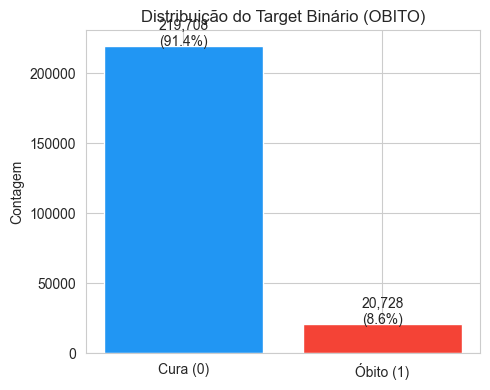

In [4]:
df = criar_target_binario(df)

# Visualizar balanceamento
contagens = df[TARGET_BINARIO].value_counts()
print(f'\nCura (0): {contagens[0]:,} | Óbito (1): {contagens[1]:,}')
print(f'Ratio desbalanceamento: {contagens[0]/contagens[1]:.2f}:1')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Cura (0)', 'Óbito (1)'], contagens.values, color=['#2196F3', '#F44336'])
ax.set_title('Distribuição do Target Binário (OBITO)')
ax.set_ylabel('Contagem')
for i, v in enumerate(contagens.values):
    ax.text(i, v + 100, f'{v:,}\n({v/sum(contagens)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_binario.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Seleção de Features

Selecionamos features clínicas relevantes agrupadas em:
- **Demográficas:** sexo, idade, raça, escolaridade, zona
- **Sintomas:** febre, tosse, dispneia, saturação, etc.
- **Comorbidades:** cardiopatia, diabetes, obesidade, etc.
- **Internação:** UTI, suporte ventilatório
- **Vacinação:** vacina influenza, COVID-19

In [5]:
df_features = selecionar_features(df)
print(f'Features selecionadas: {df_features.shape[1] - 1} variáveis + 1 target')
print(f'\nColunas:')
for col in df_features.columns:
    print(f'  - {col}: {df_features[col].dtype}')

Features selecionadas: 37 variáveis + 1 target

Colunas:
  - CS_SEXO: object
  - NU_IDADE_N: int64
  - TP_IDADE: int64
  - CS_GESTANT: int64
  - CS_RACA: int64
  - CS_ESCOL_N: float64
  - CS_ZONA: float64
  - FEBRE: float64
  - TOSSE: float64
  - GARGANTA: float64
  - DISPNEIA: float64
  - DESC_RESP: float64
  - SATURACAO: float64
  - DIARREIA: float64
  - VOMITO: float64
  - DOR_ABD: float64
  - FADIGA: float64
  - PERD_OLFT: float64
  - PERD_PALA: float64
  - PUERPERA: float64
  - CARDIOPATI: float64
  - HEMATOLOGI: float64
  - SIND_DOWN: float64
  - HEPATICA: float64
  - ASMA: float64
  - DIABETES: float64
  - NEUROLOGIC: float64
  - PNEUMOPATI: float64
  - IMUNODEPRE: float64
  - RENAL: float64
  - OBESIDADE: float64
  - HOSPITAL: float64
  - UTI: float64
  - SUPORT_VEN: float64
  - NOSOCOMIAL: float64
  - VACINA: float64
  - VACINA_COV: float64
  - OBITO: int64


## 6. Divisão dos Dados e Tratamento de Valores Ausentes

Aqui está uma parte muito importante do projeto.

Antes, a imputação estava sendo feita no dataset inteiro. Isso funciona tecnicamente, mas não é o ideal em Machine Learning, porque o modelo acaba recebendo informação indireta dos dados de validação e teste.

Agora fazemos do jeito mais correto:

1. Primeiro dividimos os dados em treino, validação e teste.
2. Depois ajustamos os imputadores apenas no treino.
3. Em seguida aplicamos a mesma regra na validação e no teste.

Isso evita o chamado **data leakage**, que é quando informação do teste "vaza" para o treino.


In [6]:
# Primeiro fazemos o split com o dataset ainda "cru" de features.
# O df_features ainda contém a coluna alvo OBITO, então a função dividir_dados consegue separar X e y.
X_train, X_val, X_test, y_train, y_val, y_test = dividir_dados(df_features)

print('Tamanhos após o split:')
print(f'Treino    — X: {X_train.shape}, y: {y_train.shape}')
print(f'Validação — X: {X_val.shape}, y: {y_val.shape}')
print(f'Teste     — X: {X_test.shape}, y: {y_test.shape}')

print('\nProporção de óbitos em cada conjunto:')
print(f'Treino:    {y_train.mean()*100:.2f}%')
print(f'Validação: {y_val.mean()*100:.2f}%')
print(f'Teste:     {y_test.mean()*100:.2f}%')

# Antes da imputação, olhamos quantos nulos existem em cada parte.
print('\nValores nulos antes da imputação:')
print(f'Treino:    {X_train.isnull().sum().sum():,}')
print(f'Validação: {X_val.isnull().sum().sum():,}')
print(f'Teste:     {X_test.isnull().sum().sum():,}')

# Agora aplicamos a imputação correta:
# - fit no treino
# - transform na validação e no teste
X_train, X_val, X_test, imputers = tratar_valores_ausentes(
    X_train,
    X_val,
    X_test
)

print('\nValores nulos após a imputação:')
print(f'Treino:    {X_train.isnull().sum().sum():,}')
print(f'Validação: {X_val.isnull().sum().sum():,}')
print(f'Teste:     {X_test.isnull().sum().sum():,}')

print('\nImputadores criados:')
print(imputers.keys())


Split — Treino: 168,304 | Validação: 36,066 | Teste: 36,066
Tamanhos após o split:
Treino    — X: (168304, 37), y: (168304,)
Validação — X: (36066, 37), y: (36066,)
Teste     — X: (36066, 37), y: (36066,)

Proporção de óbitos em cada conjunto:
Treino:    8.62%
Validação: 8.62%
Teste:     8.62%

Valores nulos antes da imputação:
Treino:    1,956,251
Validação: 421,371
Teste:     421,610


Valores ausentes após imputação — máx. por coluna (treino): 0.00%

Valores nulos após a imputação:
Treino:    0
Validação: 0
Teste:     0

Imputadores criados:
dict_keys(['numeric', 'categorical'])


## 7. Codificação de Variáveis Categóricas

Depois de tratar os nulos, precisamos transformar colunas categóricas em números.

Neste notebook usamos `OrdinalEncoder` apenas nas colunas do tipo `object`.

A lógica é a mesma da imputação:

- o encoder aprende as categorias usando somente o treino;
- depois aplica a mesma regra na validação e no teste;
- categorias desconhecidas recebem valor `-1`.

Isso mantém o processo mais correto e evita vazamento de informação.


In [7]:
# Identificar quais colunas ainda são categóricas
colunas_cat = X_train.select_dtypes(include=["object"]).columns.tolist()

encoders = {}

X_train_cod = X_train.copy()
X_val_cod = X_val.copy()
X_test_cod = X_test.copy()

if colunas_cat:
    encoder_cat = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    # Aprende as categorias apenas no treino
    X_train_cod[colunas_cat] = encoder_cat.fit_transform(X_train_cod[colunas_cat])

    # Aplica a mesma codificação na validação e no teste
    X_val_cod[colunas_cat] = encoder_cat.transform(X_val_cod[colunas_cat])
    X_test_cod[colunas_cat] = encoder_cat.transform(X_test_cod[colunas_cat])

    encoders["categorical"] = encoder_cat

print(f'Colunas categóricas codificadas: {colunas_cat if colunas_cat else "nenhuma"}')

# A partir daqui, mantemos X_train, X_val e X_test já codificados
X_train, X_val, X_test = X_train_cod, X_val_cod, X_test_cod

print('\nShapes após codificação:')
print(f'Treino:    {X_train.shape}')
print(f'Validação: {X_val.shape}')
print(f'Teste:     {X_test.shape}')

# Para fazer correlação e gráficos de EDA, juntamos temporariamente os splits.
# Isso é apenas para análise, não para treinar modelo.
df_codificado = pd.concat(
    [
        X_train.assign(**{TARGET_BINARIO: y_train.values}),
        X_val.assign(**{TARGET_BINARIO: y_val.values}),
        X_test.assign(**{TARGET_BINARIO: y_test.values}),
    ],
    axis=0
).reset_index(drop=True)

print(f'\nDataset codificado para análise: {df_codificado.shape}')
df_codificado.head(3)


Colunas categóricas codificadas: ['CS_SEXO']

Shapes após codificação:
Treino:    (168304, 37)
Validação: (36066, 37)
Teste:     (36066, 37)

Dataset codificado para análise: (240436, 38)


,CS_SEXO,NU_IDADE_N,TP_IDADE,CS_GESTANT,CS_RACA,CS_ESCOL_N,CS_ZONA,FEBRE,TOSSE,GARGANTA,DISPNEIA,DESC_RESP,SATURACAO,DIARREIA,VOMITO,DOR_ABD,FADIGA,PERD_OLFT,PERD_PALA,PUERPERA,CARDIOPATI,HEMATOLOGI,SIND_DOWN,HEPATICA,ASMA,DIABETES,NEUROLOGIC,PNEUMOPATI,IMUNODEPRE,RENAL,OBESIDADE,HOSPITAL,UTI,SUPORT_VEN,NOSOCOMIAL,VACINA,VACINA_COV,OBITO
0,2.0,82.0,3.0,6.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1
1,2.0,1.0,3.0,6.0,4.0,5.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,0
2,0.0,88.0,3.0,5.0,9.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,2.0,2.0,1.0,0


## 8. Análise de Correlação

Verificamos a correlação entre as features e o target para:
- Identificar as variáveis mais preditivas
- Detectar multicolinearidade entre features

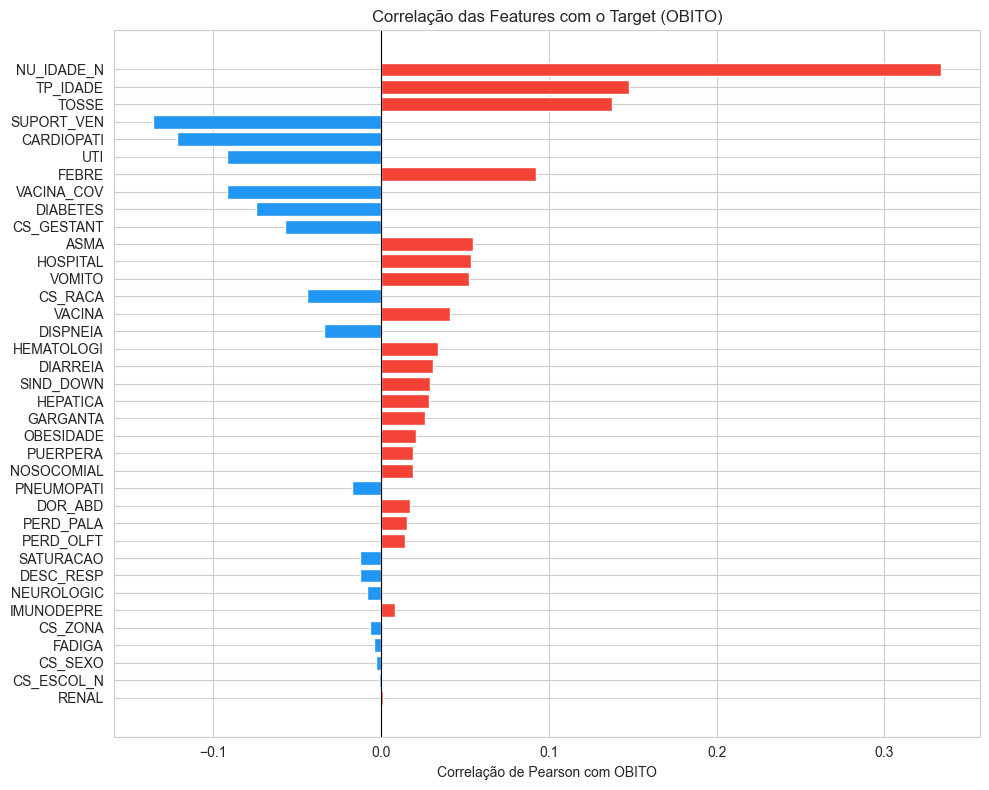


Top 10 features mais correlacionadas com OBITO:
NU_IDADE_N    0.333597
TP_IDADE      0.147958
TOSSE         0.137923
SUPORT_VEN   -0.135945
CARDIOPATI   -0.121765
UTI          -0.092242
FEBRE         0.092019
VACINA_COV   -0.091915
DIABETES     -0.074492
CS_GESTANT   -0.057239


In [8]:
# Correlação com o target
corr_target = df_codificado.corr()[TARGET_BINARIO].drop(TARGET_BINARIO).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#F44336' if v > 0 else '#2196F3' for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=cores[::-1])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson com OBITO')
ax.set_title('Correlação das Features com o Target (OBITO)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlacao_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features mais correlacionadas com OBITO:')
print(corr_target.head(10).to_string())


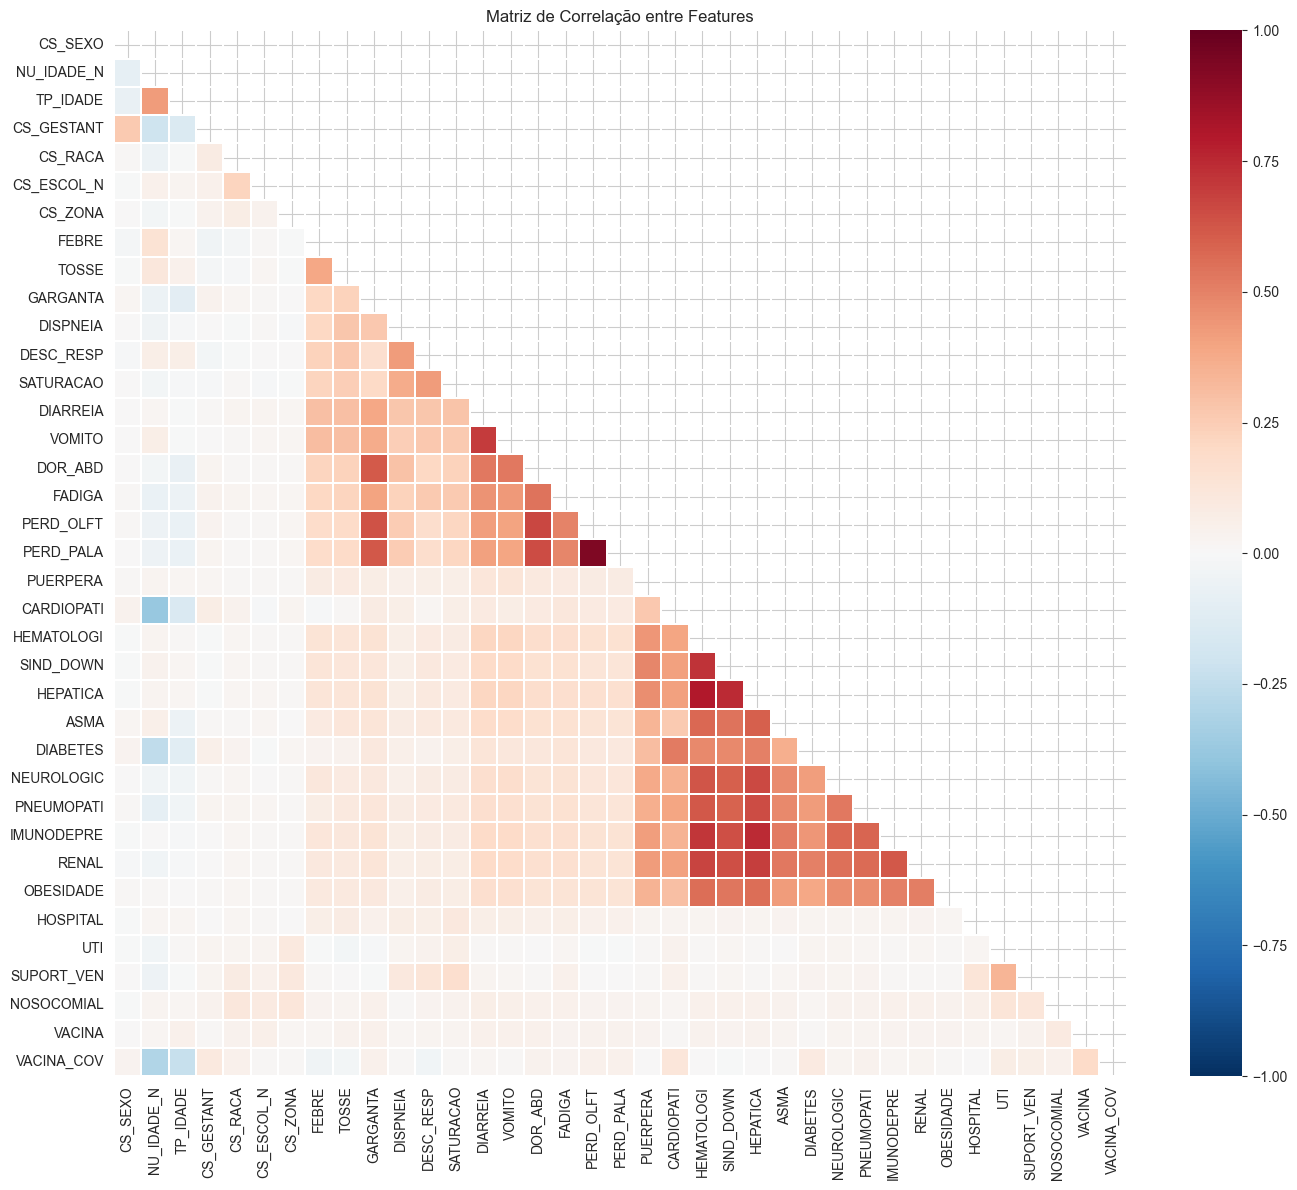

In [9]:
# Heatmap de correlação entre features
corr_matrix = df_codificado.drop(columns=[TARGET_BINARIO]).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
)
ax.set_title('Matriz de Correlação entre Features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Normalização

A normalização também precisa seguir a mesma regra:

- o `StandardScaler` é ajustado apenas no treino;
- validação e teste recebem a transformação aprendida no treino.

Isso impede que estatísticas dos dados de validação/teste influenciem o treinamento.


In [10]:
# Nesta etapa o split já foi feito antes da imputação.
# Aqui apenas conferimos novamente os tamanhos e o balanceamento.

print(f'Treino    — X: {X_train.shape}, y: {y_train.shape}')
print(f'Validação — X: {X_val.shape}, y: {y_val.shape}')
print(f'Teste     — X: {X_test.shape}, y: {y_test.shape}')

print(f'\nProporção de óbitos (treino):    {y_train.mean()*100:.1f}%')
print(f'Proporção de óbitos (validação): {y_val.mean()*100:.1f}%')
print(f'Proporção de óbitos (teste):     {y_test.mean()*100:.1f}%')


Treino    — X: (168304, 37), y: (168304,)
Validação — X: (36066, 37), y: (36066,)
Teste     — X: (36066, 37), y: (36066,)

Proporção de óbitos (treino):    8.6%
Proporção de óbitos (validação): 8.6%
Proporção de óbitos (teste):     8.6%


In [11]:
X_train_norm, X_val_norm, X_test_norm, scaler = normalizar_numericas(X_train, X_val, X_test)

print('Normalização aplicada.')
print(f'\nEstatísticas de X_train após normalização:')
print(X_train_norm.describe().T[['mean', 'std']].round(3))

Normalização aplicada.

Estatísticas de X_train após normalização:
            mean  std
CS_SEXO     -0.0  1.0
NU_IDADE_N   0.0  1.0
TP_IDADE    -0.0  1.0
CS_GESTANT   0.0  1.0
CS_RACA     -0.0  1.0
CS_ESCOL_N   0.0  1.0
CS_ZONA     -0.0  1.0
FEBRE       -0.0  1.0
TOSSE        0.0  1.0
GARGANTA     0.0  1.0
DISPNEIA    -0.0  1.0
DESC_RESP   -0.0  1.0
SATURACAO    0.0  1.0
DIARREIA     0.0  1.0
VOMITO      -0.0  1.0
DOR_ABD     -0.0  1.0
FADIGA      -0.0  1.0
PERD_OLFT   -0.0  1.0
PERD_PALA   -0.0  1.0
PUERPERA     0.0  1.0
CARDIOPATI   0.0  1.0
HEMATOLOGI  -0.0  1.0
SIND_DOWN    0.0  1.0
HEPATICA    -0.0  1.0
ASMA         0.0  1.0
DIABETES     0.0  1.0
NEUROLOGIC   0.0  1.0
PNEUMOPATI  -0.0  1.0
IMUNODEPRE   0.0  1.0
RENAL        0.0  1.0
OBESIDADE   -0.0  1.0
HOSPITAL     0.0  1.0
UTI         -0.0  1.0
SUPORT_VEN  -0.0  1.0
NOSOCOMIAL   0.0  1.0
VACINA       0.0  1.0
VACINA_COV   0.0  1.0


## 10. Salvamento dos Artefatos

Salva todos os splits e artefatos em `../data/processed/` para uso nos notebooks seguintes.

In [12]:
# Executar pipeline completo e salvar (equivalente às etapas acima)
# Use isto para re-gerar todos os artefatos de uma vez
print('Executando pipeline completo e salvando artefatos...')
artefatos = executar_pipeline_preprocessamento(df_raw, salvar=True)
print('\nArtefatos disponíveis em data/processed/:')

processed_dir = PROCESSED_DIR
for f in sorted(processed_dir.glob('*')):
    tamanho = f.stat().st_size / 1024
    print(f'  {f.name} ({tamanho:.0f} KB)')


Executando pipeline completo e salvando artefatos...


Registros após filtro de EVOLUCAO válida: 240,436 (89.7% do total)
Distribuição do target binário — Cura: 219,708 (91.4%) | Óbito: 20,728 (8.6%)


Split — Treino: 168,304 | Validação: 36,066 | Teste: 36,066


Valores ausentes após imputação — máx. por coluna (treino): 0.00%


Colunas codificadas: ['CS_SEXO']


Artefatos salvos em: /Users/arthuraugustopaulahardman/projetos/pos_fiap/fase1/tech-challenge-srag-v2/src/data/processed

Artefatos disponíveis em data/processed/:
  .gitkeep (0 KB)


## 11. Conclusões do Pré-processamento

**Resumo das decisões:**

| Etapa | Estratégia | Justificativa |
|-------|-----------|---------------|
| Filtragem | EVOLUCAO ∈ {1, 2} | Desfechos definitivos para classificação binária |
| Imputação numérica | Mediana | Robusta a outliers (ex: idades extremas) |
| Imputação categórica | Moda | Mantém a distribuição original |
| Codificação | LabelEncoder | Dataset tem variáveis ordinais (1=Sim, 2=Não, 9=Ignorado) |
| Normalização | StandardScaler | Necessário para Regressão Logística e KNN |
| Split | 70/15/15 estratificado | Mantém proporção do desbalanceamento em todos os splits |

**Próximos passos:** Notebook 03 — Modelagem